## Code to generate figure for ASpop

## Install and import libraries

In [1]:
%pip install requests pandas seaborn matplotlib

import requests
import pandas as pd
from io import StringIO
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

# warnings
import warnings
warnings.filterwarnings('ignore')

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Global settings

In [2]:
hra_pop_version = 'v1.0'
branch = 'main'

output_folder = 'output'

## Get data

In [3]:
# could also use https://apps.humanatlas.io/api/grlc/hra-pop.html#get-/cell-types-in-atlas
url = f"https://raw.githubusercontent.com/x-atlas-consortia/hra-pop/refs/heads/{branch}/output-data/{hra_pop_version}/reports/atlas-ad-hoc/cell-types-in-anatomical-structurescts-per-as.csv"

headers = {
    'Accept': 'text/csv'
}

data = requests.get(url=url, headers=headers).text

df_as = pd.read_csv(StringIO(data))
df_as

,organ,as,as_label,sex,tool,modality,cell_id,cell_label,cell_count,cell_percentage,dataset_count
0,large intestine,http://purl.obolibrary.org/obo/UBERON_0001052,rectum,Female,celltypist,sc_transcriptomics,https://purl.org/ccf/ASCTB-TEMP_colonocyte,Colonocyte,1.205,0.147653,3
1,large intestine,http://purl.obolibrary.org/obo/UBERON_0001052,rectum,Female,celltypist,sc_transcriptomics,https://purl.org/ccf/ASCTB-TEMP_iga-plasma-cell,IgA plasma cell,1.182,0.144835,3
2,large intestine,http://purl.obolibrary.org/obo/UBERON_0001052,rectum,Female,celltypist,sc_transcriptomics,https://purl.org/ccf/ASCTB-TEMP_best4-epithelial,BEST4+ epithelial,0.699,0.085651,3
3,large intestine,http://purl.obolibrary.org/obo/UBERON_0001052,rectum,Female,celltypist,sc_transcriptomics,https://purl.org/ccf/ASCTB-TEMP_activated-cd4-t,Activated CD4 T,0.690,0.084548,3
4,large intestine,http://purl.obolibrary.org/obo/UBERON_0001052,rectum,Female,celltypist,sc_transcriptomics,https://purl.org/ccf/ASCTB-TEMP_ta,TA,0.540,0.066168,3
...,...,...,...,...,...,...,...,...,...,...,...
8891,lung,http://purl.org/sig/ont/fma/fma7508,Left posterior basal segmental bronchus,Male,sc_proteomics,sc_proteomics,http://purl.obolibrary.org/obo/CL_0000097,Mast Cell,15322.464,0.024702,1
8892,lung,http://purl.org/sig/ont/fma/fma7508,Left posterior basal segmental bronchus,Male,sc_proteomics,sc_proteomics,http://purl.obolibrary.org/obo/CL_4033039,CD8+ T Cell,3691.176,0.005951,1
8893,lung,http://purl.org/sig/ont/fma/fma7508,Left posterior basal segmental bronchus,Male,sc_proteomics,sc_proteomics,https://purl.org/ccf/ASCTB-TEMP_lymphatic-endo...,Lymphatic Endothelial (and some immune cells),1753.956,0.002828,1
8894,lung,http://purl.org/sig/ont/fma/fma7508,Left posterior basal segmental bronchus,Male,sc_proteomics,sc_proteomics,https://purl.org/ccf/ASCTB-TEMP_basal-epitheli...,Basal Epithelial Cell,970.104,0.001564,1


## Preprocess

In [4]:
# filter out sc-proteomics
df_as = df_as[df_as["tool"] != "sc_proteomics"]
df_as

,organ,as,as_label,sex,tool,modality,cell_id,cell_label,cell_count,cell_percentage,dataset_count
0,large intestine,http://purl.obolibrary.org/obo/UBERON_0001052,rectum,Female,celltypist,sc_transcriptomics,https://purl.org/ccf/ASCTB-TEMP_colonocyte,Colonocyte,1.205,1.476535e-01,3
1,large intestine,http://purl.obolibrary.org/obo/UBERON_0001052,rectum,Female,celltypist,sc_transcriptomics,https://purl.org/ccf/ASCTB-TEMP_iga-plasma-cell,IgA plasma cell,1.182,1.448352e-01,3
2,large intestine,http://purl.obolibrary.org/obo/UBERON_0001052,rectum,Female,celltypist,sc_transcriptomics,https://purl.org/ccf/ASCTB-TEMP_best4-epithelial,BEST4+ epithelial,0.699,8.565127e-02,3
3,large intestine,http://purl.obolibrary.org/obo/UBERON_0001052,rectum,Female,celltypist,sc_transcriptomics,https://purl.org/ccf/ASCTB-TEMP_activated-cd4-t,Activated CD4 T,0.690,8.454846e-02,3
4,large intestine,http://purl.obolibrary.org/obo/UBERON_0001052,rectum,Female,celltypist,sc_transcriptomics,https://purl.org/ccf/ASCTB-TEMP_ta,TA,0.540,6.616836e-02,3
...,...,...,...,...,...,...,...,...,...,...,...
8879,lung,http://purl.org/sig/ont/fma/fma7508,Left posterior basal segmental bronchus,Male,popv,sc_transcriptomics,http://purl.obolibrary.org/obo/CL_0000192,smooth muscle cell,18.000,5.873818e-05,27
8880,lung,http://purl.org/sig/ont/fma/fma7508,Left posterior basal segmental bronchus,Male,popv,sc_transcriptomics,http://purl.obolibrary.org/obo/CL_0017000,pulmonary ionocyte,9.000,2.936909e-05,27
8881,lung,http://purl.org/sig/ont/fma/fma7508,Left posterior basal segmental bronchus,Male,popv,sc_transcriptomics,http://purl.obolibrary.org/obo/CL_0000077,mesothelial cell,7.000,2.284263e-05,27
8882,lung,http://purl.org/sig/ont/fma/fma7508,Left posterior basal segmental bronchus,Male,popv,sc_transcriptomics,http://purl.obolibrary.org/obo/CL_2000008,microvascular endothelial cell,2.000,6.526465e-06,27


In [5]:
# get nunique() cell_label by tool per as_label by sex
new_df = (
    df_as.groupby(['tool', 'sex','organ'])["cell_label"]
      .nunique()
      .reset_index(name='n_unique_cell_label')
)
new_df['organ'] = new_df['organ'].str.lower()
new_df

,tool,sex,organ,n_unique_cell_label
0,azimuth,Female,left kidney,49
1,azimuth,Female,left ureter,39
2,azimuth,Female,right kidney,49
3,azimuth,Female,right ureter,23
4,azimuth,Female,heart,21
5,azimuth,Female,lung,43
6,azimuth,Female,pancreas,5
7,azimuth,Male,left kidney,48
8,azimuth,Male,left ureter,33
9,azimuth,Male,right kidney,48


In [6]:
# add organ label to AS label
new_df['organ_as_label'] = new_df['organ'] 
# + ' - ' + new_df['as_label']

new_df['organ_as_label'] = pd.Categorical(
    new_df['organ_as_label'],
    categories=sorted(new_df["organ_as_label"].unique()),
    ordered=True
    )

# new_df['organ_as_label'] = new_df['organ_as_label'].str.lower()
new_df

,tool,sex,organ,n_unique_cell_label,organ_as_label
0,azimuth,Female,left kidney,49,left kidney
1,azimuth,Female,left ureter,39,left ureter
2,azimuth,Female,right kidney,49,right kidney
3,azimuth,Female,right ureter,23,right ureter
4,azimuth,Female,heart,21,heart
5,azimuth,Female,lung,43,lung
6,azimuth,Female,pancreas,5,pancreas
7,azimuth,Male,left kidney,48,left kidney
8,azimuth,Male,left ureter,33,left ureter
9,azimuth,Male,right kidney,48,right kidney


In [7]:
new_df["tool"] = new_df["tool"].map(
    {
        "azimuth": "Azimuth",
        "celltypist": "CellTypist",
        "popv": "popV",
    }
)

## Visualize

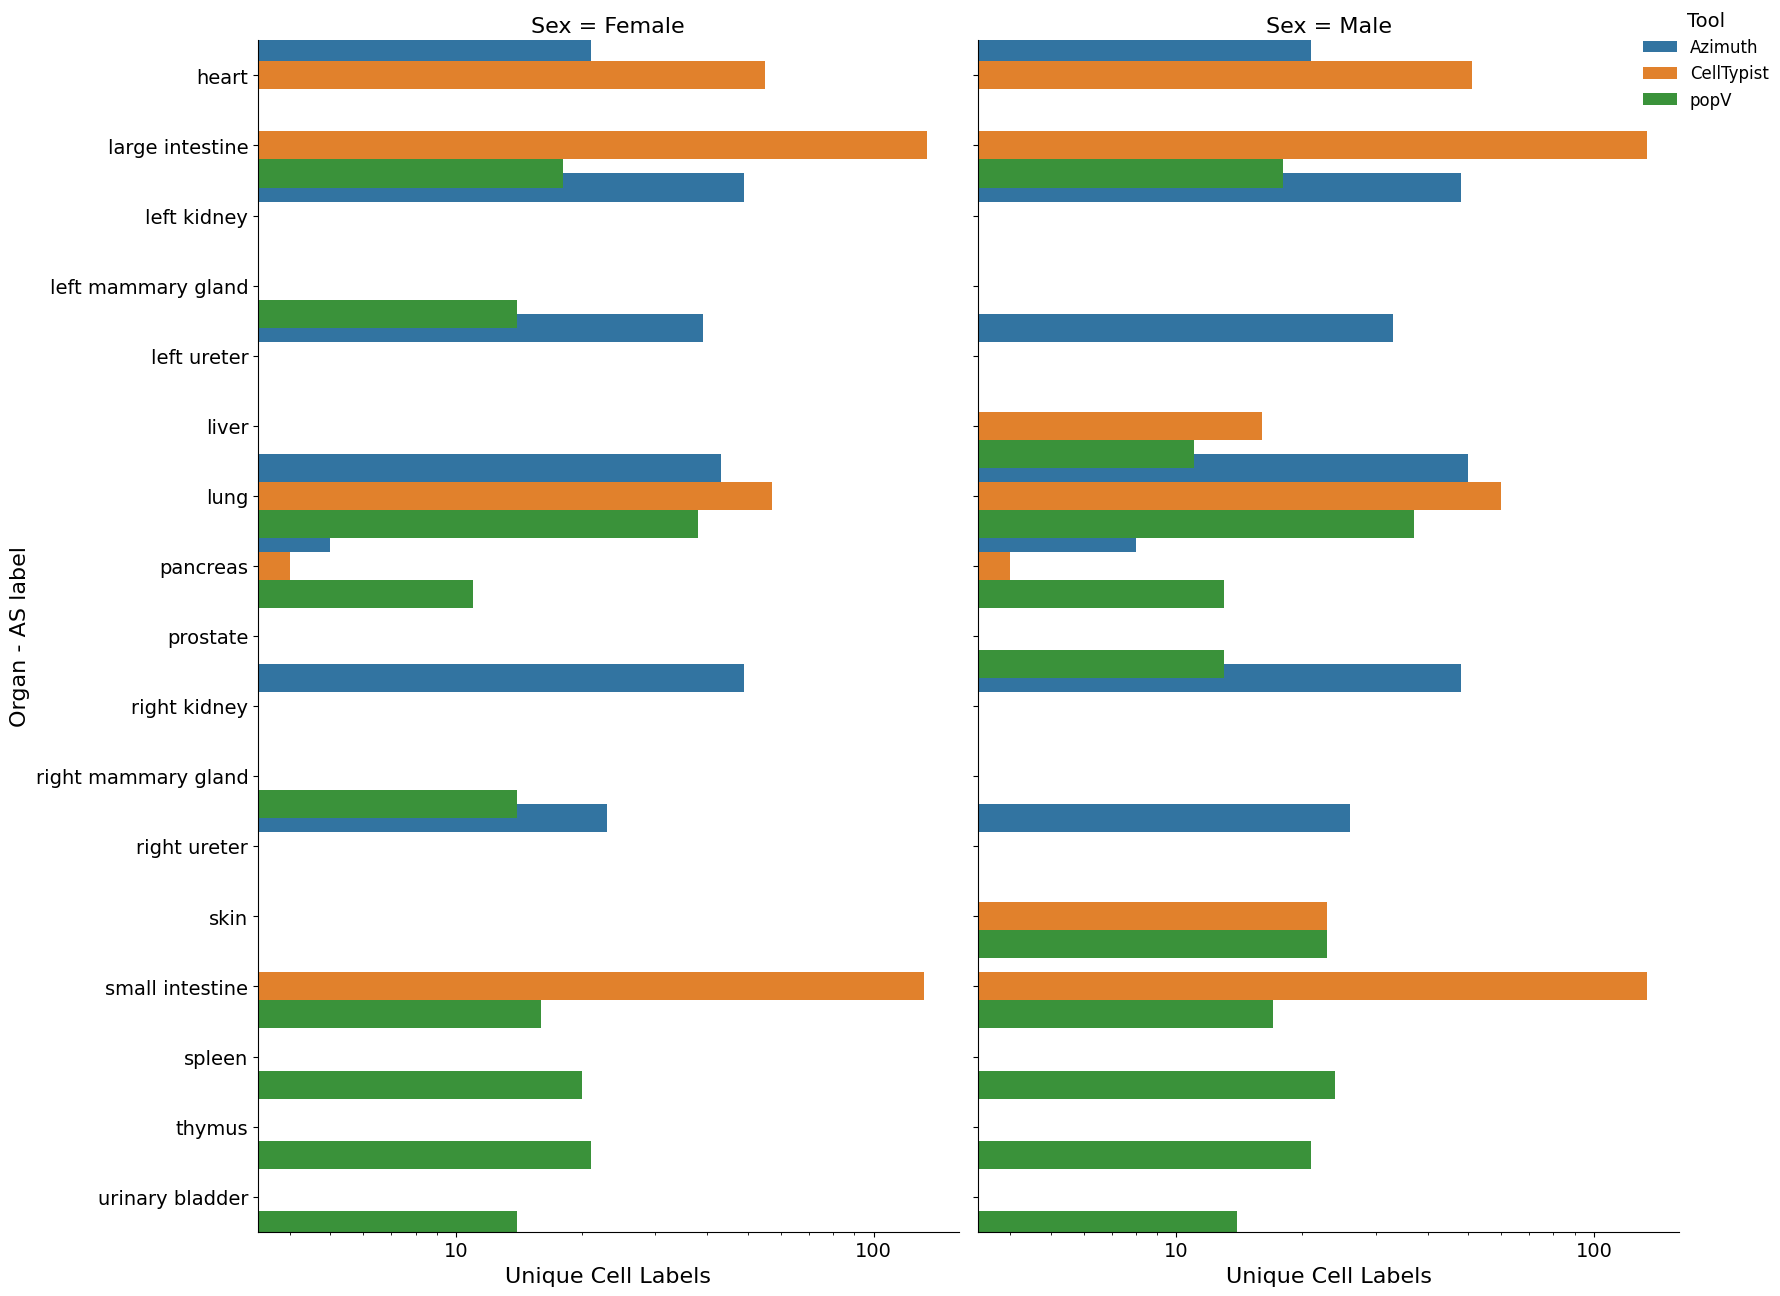

In [8]:
rc_params = {
    "figure.figsize": (12, 12),
    "axes.titlesize": 18,    # subplot titles
    "axes.labelsize": 16,    # x/y labels
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.title_fontsize": 14,
    "legend.fontsize": 12
}
plt.rcParams.update(rc_params)

# Split by sex in separate facets
g = sns.catplot(
    data=new_df,
    kind="bar",
    y="organ_as_label",
    x="n_unique_cell_label",
    hue="tool",
    col="sex",
    orient="h",
    height=13,
    aspect=.6,
    width=1.2
)

for ax in g.axes.flat:
    ax.set_xscale("log")
    formatter = ScalarFormatter()
    formatter.set_scientific(False)
    formatter.set_useOffset(False)
    ax.xaxis.set_major_formatter(formatter)

# Move legend to top right
g._legend.set_title("Tool")
g._legend.set_bbox_to_anchor((1.05, 1))  # move outside
g._legend.set_loc("upper right")

g.set_axis_labels("Unique Cell Labels", "Organ - AS label")
g.set_titles("Sex = {col_name}")
# plt.xscale('log')
plt.tight_layout()
plt.show()